# **Data Loading**

We have downloaded the clinical and genomic data of 12 studies, taken from the TCGA, PanCancer Atlas study.

The TCGA PanCancer Atlas dataset contains data:
- Normalized across cancer types
- Currently clinical data, mutations, copy number, RNAseq

This combined study contains samples from:
- Adrenocortical Carcinoma
- Bladder Urothelial Carcinoma
- Brain Lower Grade Glioma
- Breast Invasive Carcinoma
- Cervical Squamous Cell Carcinoma
- Colorectal Adenocarcinoma
- Esophageal Adenocarcinoma
- Glioblastoma Multiforme
- Head and Neck Squamous Cell Carcinoma
- Stomach Adenocarcinoma

In [1]:
## imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

for every tumor type, we create a dataframe relying on the *data_mrna_seq_v2_rsem.txt* and the *data_mutations.txt* files. Each cancer-specific study also contain a *normal* file folder, containing data for non-mutated samples.

In [2]:
def load_data(file_path):
    df = pd.read_csv(file_path, sep='\t', low_memory=False)
    return df

Start by understanding the content of the datasets with the *metadata.txt* files.

Taking the 'adrenocortical' cancer folder as an example.

- We observe that the expression dataset contains mRNA Expression, RSEM (Batch normalized from Illumina HiSeq_RNASeqV2).
- the Mutations.txt data contains information about the mutated data.


In [3]:
adrenoc_exp_meta = load_data("adrenocortical\meta_mrna_seq_v2_rsem.txt")
adrenoc_exp_meta

,cancer_study_identifier: acc_tcga_pan_can_atlas_2018
0,stable_id: rna_seq_v2_mrna
1,genetic_alteration_type: MRNA_EXPRESSION
2,datatype: CONTINUOUS
3,show_profile_in_analysis_tab: FALSE
4,"profile_name: mRNA Expression, RSEM (Batch nor..."
5,"profile_description:mRNA Expression, RSEM (Bat..."
6,data_filename: data_mrna_seq_v2_rsem.txt


In [4]:
adrenoc_mut_meta = load_data("adrenocortical\meta_mutations.txt")
adrenoc_mut_meta

,cancer_study_identifier: acc_tcga_pan_can_atlas_2018
0,genetic_alteration_type: MUTATION_EXTENDED
1,datatype: MAF
2,stable_id: mutations
3,show_profile_in_analysis_tab: true
4,profile_description: Mutation data from whole ...
5,profile_name: Mutations
6,data_filename: data_mutations.txt


Dataset *data_mrna_seq_v2_rsem.txt* is a log-transformed gene expression matrix for normal samples only.

- Each row = a gene
- Each column (after first two) = a normal tissue sample (identified by TCGA barcode), with the unique patient identifier
- Values = normalized expression levels (likely log2(norm_count + 1), e.g., from RSEM)

- 11 at the end of the TCGA sample ID means it's from normal (solid tissue):
    - 01 = primary tumor
    - 11 = solid tissue normal
    - 06 = metastasis
etc.


log RNA Seq V2 RSEM:

Log-transformed mRNA expression z-scores compared to the expression distribution of all samples (RNA Seq V2 RSEM).

## **Merge Mutation - Expression**

In [5]:
# common for all the cancer studies
exp_path = "data_mrna_seq_v2_rsem.txt"
mut_path = "data_mutations.txt"

In [6]:
def create_exp_df(cancer_type):
    df = load_data(f"{cancer_type}\{exp_path}")
    df = df.dropna(subset= ['Hugo_Symbol'])
    df.set_index("Hugo_Symbol", inplace=True)
    df = df.drop(columns=['Entrez_Gene_Id'], errors='ignore')
    df = df.T
    df.index.name = 'Patient_ID'
    return df

def create_mut_df(cancer_type):
    df = load_data(f"{cancer_type}\{mut_path}")
    df = df[df['Annotation_Status']=='SUCCESS']
    df = pd.DataFrame({'Hugo_Symbol': df['Hugo_Symbol'].to_list(),
                            'Patient_ID':df['Tumor_Sample_Barcode'].to_list(),
                            'Mutation_Type': df['Variant_Type'].to_list(),
                            'Protein_Conseq': df["Variant_Classification"].to_list(),
                            'Impact': df['IMPACT'].to_list(),
                            'Is_Damaging': df['PolyPhen'].to_list(),
                            'Functional_Conseq': df['SIFT'].to_list()}
                            )
    df = df[df['Hugo_Symbol']=='TP53']
    df.set_index('Patient_ID', inplace=True)

    #remove rows with duplicate patient ids
    df.drop_duplicates()
    dupls = set([id for id in df.index.to_list() if df.index.value_counts().loc[id]>1])
    df = df.loc[df.index.difference(dupls)]
    return df

We notice that some of the dataset could not always be clean: for example, *bladder_df* contains $13$ genes having $\texttt{NaN}$ *Hugo_Symbol* and numerical Gene_ID.

Despite the gene being uniquely identifiable in the dataset, it is safer to remove them from the dataset.

In [7]:
df = load_data("bladder\data_mrna_seq_v2_rsem.txt")
df = df.loc[:, ~df.columns.str.contains('^Unnamed', na=False)]
np.sum(df['Hugo_Symbol'].isna().to_list())

13

Then, taking as an example the first study about adrenocortical cancer, we start preprocessing the dataset to obtain a dataset that can be easily handled in our analysis.

In [8]:
adrenoc_exp = create_exp_df('adrenocortical')
adrenoc_mut = create_mut_df('adrenocortical')
adrenoc_exp.head(5)

Hugo_Symbol,NUDT18,SHC3,NCRNA00112,FAM49B,FMO6P,BAT2L2,SIRT1,MSLNL,ATG4A,ESPN,...,SCARNA6,SNORD77,TLR10,GKN2,PCDHGB4,ZMAT5,AXIN2,LONRF1,KLHL10,C12orf36
Patient_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J1-01,85.0144,97.5024,0.0,671.950,0.0,2428.43,462.056,0.0,385.687,20.1729,...,0.0000,0.0,12.0077,0.0,17.2911,913.535,547.5500,363.112,1.9212,0.0
TCGA-OR-A5J2-01,165.8840,92.6050,0.0,812.911,0.0,5097.30,669.977,0.0,547.980,2.8184,...,0.4026,0.0,0.8053,0.0,268.9890,303.978,1793.3200,592.672,0.0000,0.0
TCGA-OR-A5J3-01,309.2880,10.0726,0.0,482.299,0.0,1615.76,514.294,0.0,1125.170,38.5128,...,0.5925,0.0,0.0000,0.0,689.4860,324.592,522.5890,456.821,0.0000,0.0
TCGA-OR-A5J5-01,178.9310,49.5740,0.0,466.305,0.0,1202.17,591.789,0.0,525.949,10.8443,...,0.0000,0.0,6.9713,0.0,54.2215,790.550,337.7230,484.895,1.5492,0.0
TCGA-OR-A5J6-01,124.0660,5.5886,0.0,1074.680,0.0,1424.53,805.312,0.0,279.987,3.9120,...,1.6766,0.0,1.1177,0.0,8.9417,291.550,9.5006,628.155,1.1177,0.0


We want the patient IDs to be unique in the dataset.

If the patient is associated with more than one type of mutation (both are detected), then we delete them in order to prevent ambiguous information, since the classifier will associate each patient with a unique type of mutation.
In the case of the adrenocortical cancer study, only 2 patients were duplicated (hence 4 rows were removed)

In [10]:
adrenoc_mut

,Hugo_Symbol,Mutation_Type,Protein_Conseq,Impact,Is_Damaging,Functional_Conseq
Patient_ID,,,,,,
TCGA-OR-A5J2-01,TP53,DEL,Frame_Shift_Del,HIGH,.,.
TCGA-OR-A5J5-01,TP53,SNP,Missense_Mutation,MODERATE,probably_damaging(0.998),deleterious(0)
TCGA-OR-A5J8-01,TP53,SNP,Splice_Region,LOW,.,.
TCGA-OR-A5JB-01,TP53,SNP,Missense_Mutation,MODERATE,probably_damaging(0.992),deleterious(0)
TCGA-OR-A5JG-01,TP53,SNP,Splice_Site,HIGH,.,.
TCGA-OR-A5JJ-01,TP53,SNP,Missense_Mutation,MODERATE,probably_damaging(0.955),deleterious(0)
TCGA-OR-A5JL-01,TP53,DEL,Frame_Shift_Del,HIGH,.,.
TCGA-OR-A5JP-01,TP53,INS,Frame_Shift_Ins,HIGH,.,.
TCGA-OR-A5K4-01,TP53,SNP,Missense_Mutation,MODERATE,probably_damaging(0.975),tolerated(0.09)


In [11]:
adrenoc_mut['Protein_Conseq'].value_counts()

Protein_Conseq
Missense_Mutation    5
Frame_Shift_Del      3
Splice_Site          2
Frame_Shift_Ins      2
Nonsense_Mutation    2
Splice_Region        1
In_Frame_Del         1
Name: count, dtype: int64

*PolyPhen*: (Polymorphism Phenotyping v2)

predicts the impact of amino acid substitutions on protein structure and function. Its score ranges from 0.0 to 1.0, with closer to 1.0 corresponding to more likely damaging.

Qualitative interpretation:
- benign (e.g. benign(0.01))
- possibly_damaging (e.g. possibly_damaging(0.65))
- probably_damaging (e.g. probably_damaging(0.998))

*SIFT* (Sorting Intolerant From Tolerant):

predicts whether an amino acid substitution affects protein function, based on sequence conservation. The score range here is again in the range [0.0, 1.0], but it is reversed:

- $<0.05 \mapsto$ deleterious
- $\geq 0.05 \mapsto$ non-deleterious

So deleterious(0) means that SIFT is maximally confident ($0$ = worst tolerated) that the mutation harms protein function.

now merge the two datasets:
- add a column: Is_Mutated with binary values
    - 0: not mutated
    - 1: mutated
- add another column: Mutation_Type
    - add WT (*Wild-Type*), which means that no mutation is present in the gene of interest

In [12]:
mutated_patients = set(adrenoc_mut.index)
mutated_patients

{'TCGA-OR-A5J2-01',
 'TCGA-OR-A5J5-01',
 'TCGA-OR-A5J8-01',
 'TCGA-OR-A5JB-01',
 'TCGA-OR-A5JG-01',
 'TCGA-OR-A5JJ-01',
 'TCGA-OR-A5JL-01',
 'TCGA-OR-A5JP-01',
 'TCGA-OR-A5K4-01',
 'TCGA-OR-A5KO-01',
 'TCGA-OR-A5KY-01',
 'TCGA-OR-A5KZ-01',
 'TCGA-OR-A5LE-01',
 'TCGA-OR-A5LJ-01',
 'TCGA-PK-A5HB-01',
 'TCGA-PK-A5HC-01'}

In [13]:
def create_merged_df(cancer_type):
    exp_df = create_exp_df(cancer_type)
    mut_df = create_mut_df(cancer_type)
    mutated_patients = set(mut_df.index)
    merged_df = exp_df.copy()

    # add binary indicator for mutated samples
    merged_df['Mutated'] = exp_df.index.isin(mutated_patients).astype(int)

    # add classes for the types of mutations
    merged_df['Mutation_Type'] = merged_df.index.map(mut_df['Mutation_Type']).fillna('WT')
    merged_df['Protein_Conseq'] = merged_df.index.map(mut_df['Protein_Conseq'])
    merged_df['Functional_Conseq'] = merged_df.index.map(mut_df['Functional_Conseq'])
    mask = (merged_df['Mutated'] == 1) & (merged_df['Functional_Conseq'] == '.')
    merged_df.loc[mask, 'Functional_Conseq'] = np.nan

    # add column with tumor type
    merged_df['Tumor_Type'] = cancer_type

    return merged_df
    

In [14]:
adrenoc_df = create_merged_df('adrenocortical')

In [15]:
adrenoc_df.head()

Hugo_Symbol,NUDT18,SHC3,NCRNA00112,FAM49B,FMO6P,BAT2L2,SIRT1,MSLNL,ATG4A,ESPN,...,ZMAT5,AXIN2,LONRF1,KLHL10,C12orf36,Mutated,Mutation_Type,Protein_Conseq,Functional_Conseq,Tumor_Type
Patient_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J1-01,85.0144,97.5024,0.0,671.950,0.0,2428.43,462.056,0.0,385.687,20.1729,...,913.535,547.5500,363.112,1.9212,0.0,0,WT,NaN,NaN,adrenocortical
TCGA-OR-A5J2-01,165.8840,92.6050,0.0,812.911,0.0,5097.30,669.977,0.0,547.980,2.8184,...,303.978,1793.3200,592.672,0.0000,0.0,1,DEL,Frame_Shift_Del,NaN,adrenocortical
TCGA-OR-A5J3-01,309.2880,10.0726,0.0,482.299,0.0,1615.76,514.294,0.0,1125.170,38.5128,...,324.592,522.5890,456.821,0.0000,0.0,0,WT,NaN,NaN,adrenocortical
TCGA-OR-A5J5-01,178.9310,49.5740,0.0,466.305,0.0,1202.17,591.789,0.0,525.949,10.8443,...,790.550,337.7230,484.895,1.5492,0.0,1,SNP,Missense_Mutation,deleterious(0),adrenocortical
TCGA-OR-A5J6-01,124.0660,5.5886,0.0,1074.680,0.0,1424.53,805.312,0.0,279.987,3.9120,...,291.550,9.5006,628.155,1.1177,0.0,0,WT,NaN,NaN,adrenocortical


*Remark)*
- can sometimes find $\mathtt{NaN}$ in the 'Functional_Conseq' even though the sample has mutated TP53 $\mapsto$ sample is mutated, but no recorded data about the consequences

different ways of classifying
- actual mutation (ATACA)
- type of mutation (single pt, insertion, deletion)
- consequence on protein (missense, nonsense, silent) --> makes sense to look at it
- functional consequences (deleterious, non)

1673 : tot

986: mut

Load all data and extrapolate statistics about classes / samples to compare them

Thus, before proceding, the function *create_exp_df* is accordingly modified.

In [16]:
bladder_df = create_merged_df('bladder')
brain_df = create_merged_df('brain')
breast_df = create_merged_df('breast_invasive')
cervical_df = create_merged_df('cervical_sq')
colorec_df = create_merged_df('colorectal')
esophageal_df = create_merged_df('esophageal')
glioblast_df = create_merged_df('glioblastoma')
head_neck_df = create_merged_df('head_neck_sq')
stomach_df = create_merged_df('stomach')

In [17]:
tcga_study = {'Adrenocortical': adrenoc_df,
              'Bladder': bladder_df,
              'Brain': brain_df,
              'Breast': breast_df,
              'Cervical': cervical_df,
              'Colorectal': colorec_df,
              'Esophageal': esophageal_df,
              'Glioblastoma': glioblast_df,
              'Head_Neck': head_neck_df,
              'Stomach': stomach_df}

In [18]:
print("Shape: total # patients x # genes")
for cancer, df in tcga_study.items():
    print(f"{cancer}: {len(df), len(df.T)-5}")

Shape: total # patients x # genes
Adrenocortical: (78, 20518)
Bladder: (407, 20518)
Brain: (514, 20518)
Breast: (1082, 20518)
Cervical: (294, 20518)
Colorectal: (592, 20518)
Esophageal: (181, 20518)
Glioblastoma: (160, 20518)
Head_Neck: (515, 20518)
Stomach: (412, 20518)


all have the same number of genes (need to check if the set of genes coincide too)

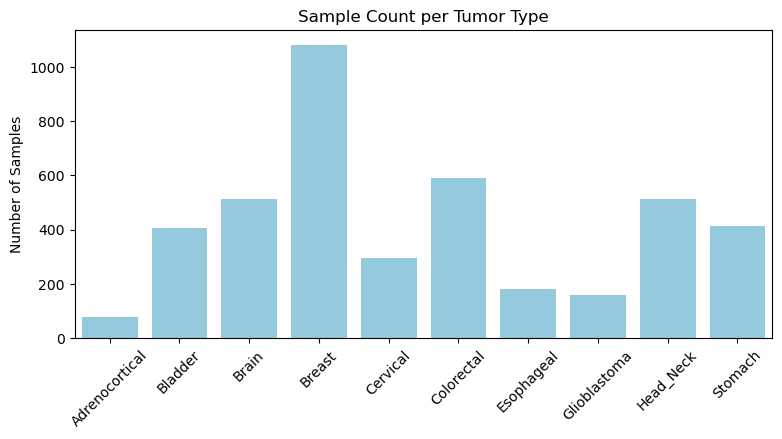

In [19]:
def plot_sample_counts(cancer_df_dict):
    sizes = [len(df) for df in cancer_df_dict.values()]
    plt.figure(figsize=(9, 4))
    sns.barplot(x=cancer_df_dict.keys(), y=sizes, color='skyblue')
    plt.xticks(rotation=45)
    plt.ylabel('Number of Samples')
    plt.title('Sample Count per Tumor Type')
    plt.show()

plot_sample_counts(tcga_study)

From this plot, we see that each study has different number of samples.

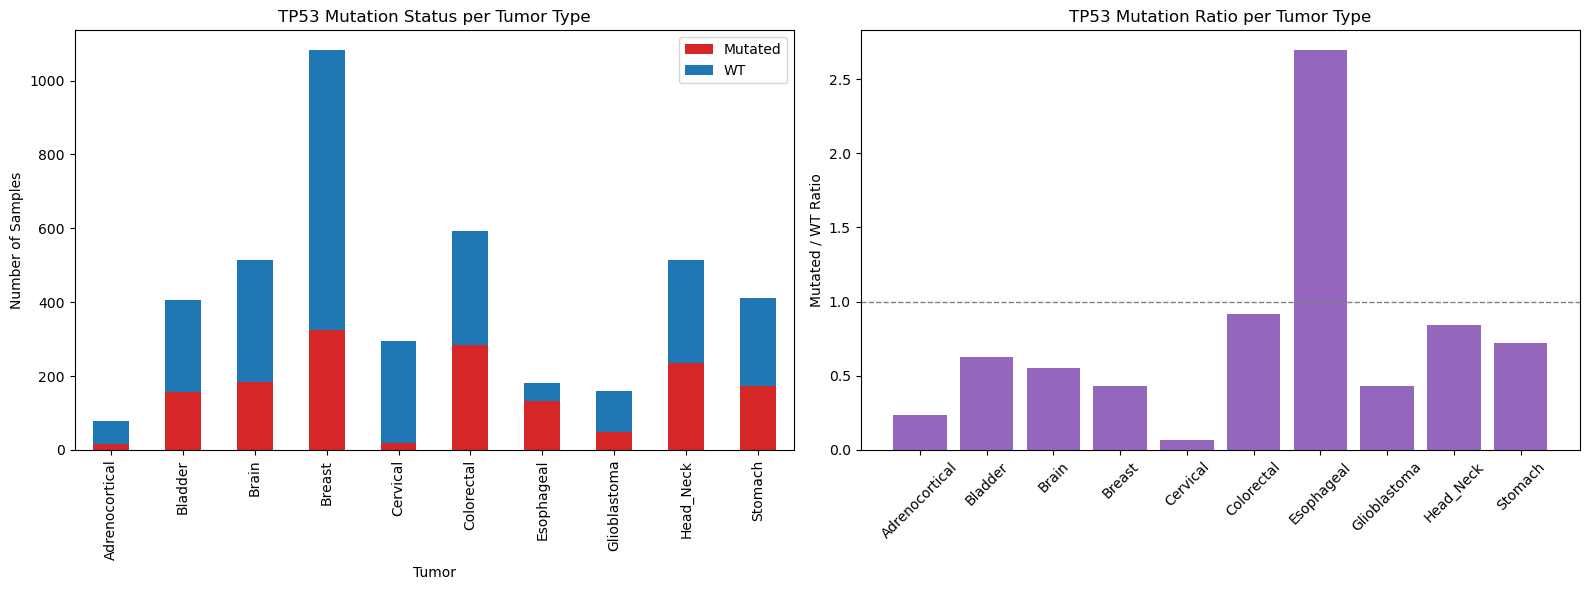

In [20]:
def plot_mutation_balance_and_ratio(cancer_df_dict):
    data = []
    tumor_names = []
    ratios = []

    for df, tumor in zip(cancer_df_dict.values(), cancer_df_dict.keys()):
        counts = df['Mutated'].value_counts()
        mutated = counts.get(1, 0)
        wt = counts.get(0, 0)
        data.append({'Tumor': tumor, 'Mutated': mutated, 'WT': wt})
        tumor_names.append(tumor)
        ratios.append(mutated / wt if wt != 0 else float('inf'))

    df_plot = pd.DataFrame(data).set_index('Tumor')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Mutation counts
    df_plot.plot(kind='bar', stacked=True, color=['#d62728', '#1f77b4'], ax=axes[0])
    axes[0].set_title('TP53 Mutation Status per Tumor Type',)
    axes[0].set_ylabel('Number of Samples')

    # Plot 2: Mutation ratio
    axes[1].bar(tumor_names, ratios, color='#9467bd')
    axes[1].axhline(1, color='gray', linestyle='--', linewidth=1)
    axes[1].set_title('TP53 Mutation Ratio per Tumor Type')
    axes[1].set_ylabel('Mutated / WT Ratio')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

plot_mutation_balance_and_ratio(tcga_study)

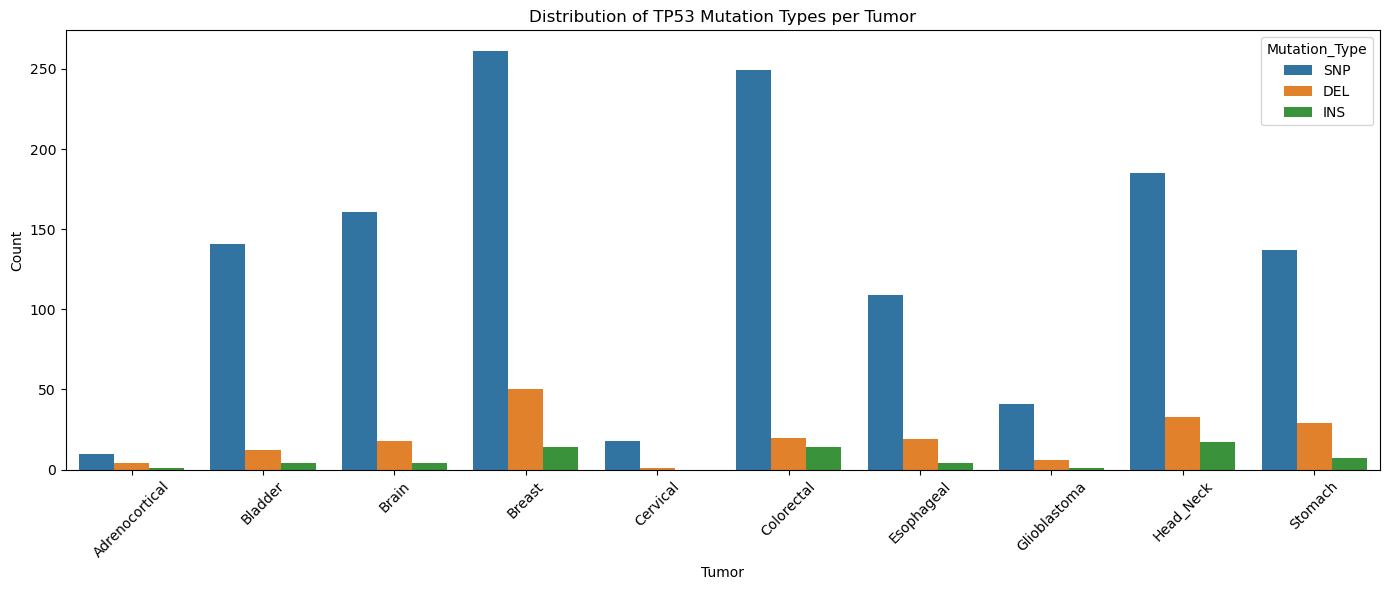

In [21]:
def plot_mutation_type(cancer_df_dict):
    all_counts = []
    for df, tumor in zip(cancer_df_dict.values(), cancer_df_dict.keys()):

        counts = df[df['Mutated'] == 1]['Mutation_Type'].value_counts()
        for mtype, count in counts.items():
            all_counts.append({'Tumor': tumor, 'Mutation_Type': mtype, 'Count': count})
    
    count_df = pd.DataFrame(all_counts)
    #print(count_df)
    plt.figure(figsize=(14, 6))
    sns.barplot(x='Tumor', y='Count', hue='Mutation_Type', data=count_df)
    plt.title('Distribution of TP53 Mutation Types per Tumor')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_mutation_type(tcga_study)    

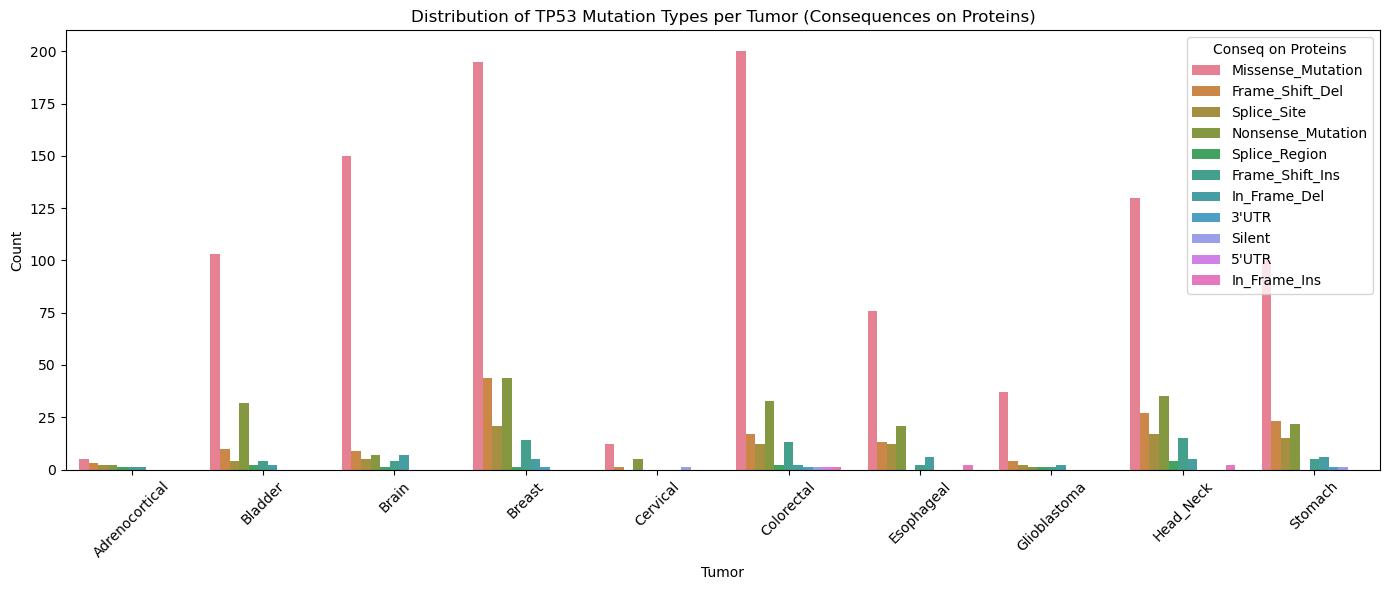

In [22]:
def plot_protein_conseq(cancer_df_dict):
    all_counts = []
    for df, tumor in zip(cancer_df_dict.values(), cancer_df_dict.keys()):

        counts = df[df['Mutated'] == 1]['Protein_Conseq'].value_counts()
        for mtype, count in counts.items():
            all_counts.append({'Tumor': tumor, 'Conseq on Proteins': mtype, 'Count': count})
    
    count_df = pd.DataFrame(all_counts)
    plt.figure(figsize=(14, 6))
    sns.barplot(x='Tumor', y='Count', hue='Conseq on Proteins', data=count_df)
    plt.title('Distribution of TP53 Mutation Types per Tumor (Consequences on Proteins)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_protein_conseq(tcga_study)

C:\Users\Utente\AppData\Local\Temp\ipykernel_18724\530254989.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = plt.cm.get_cmap('tab20', len(unique_protein_conseq))


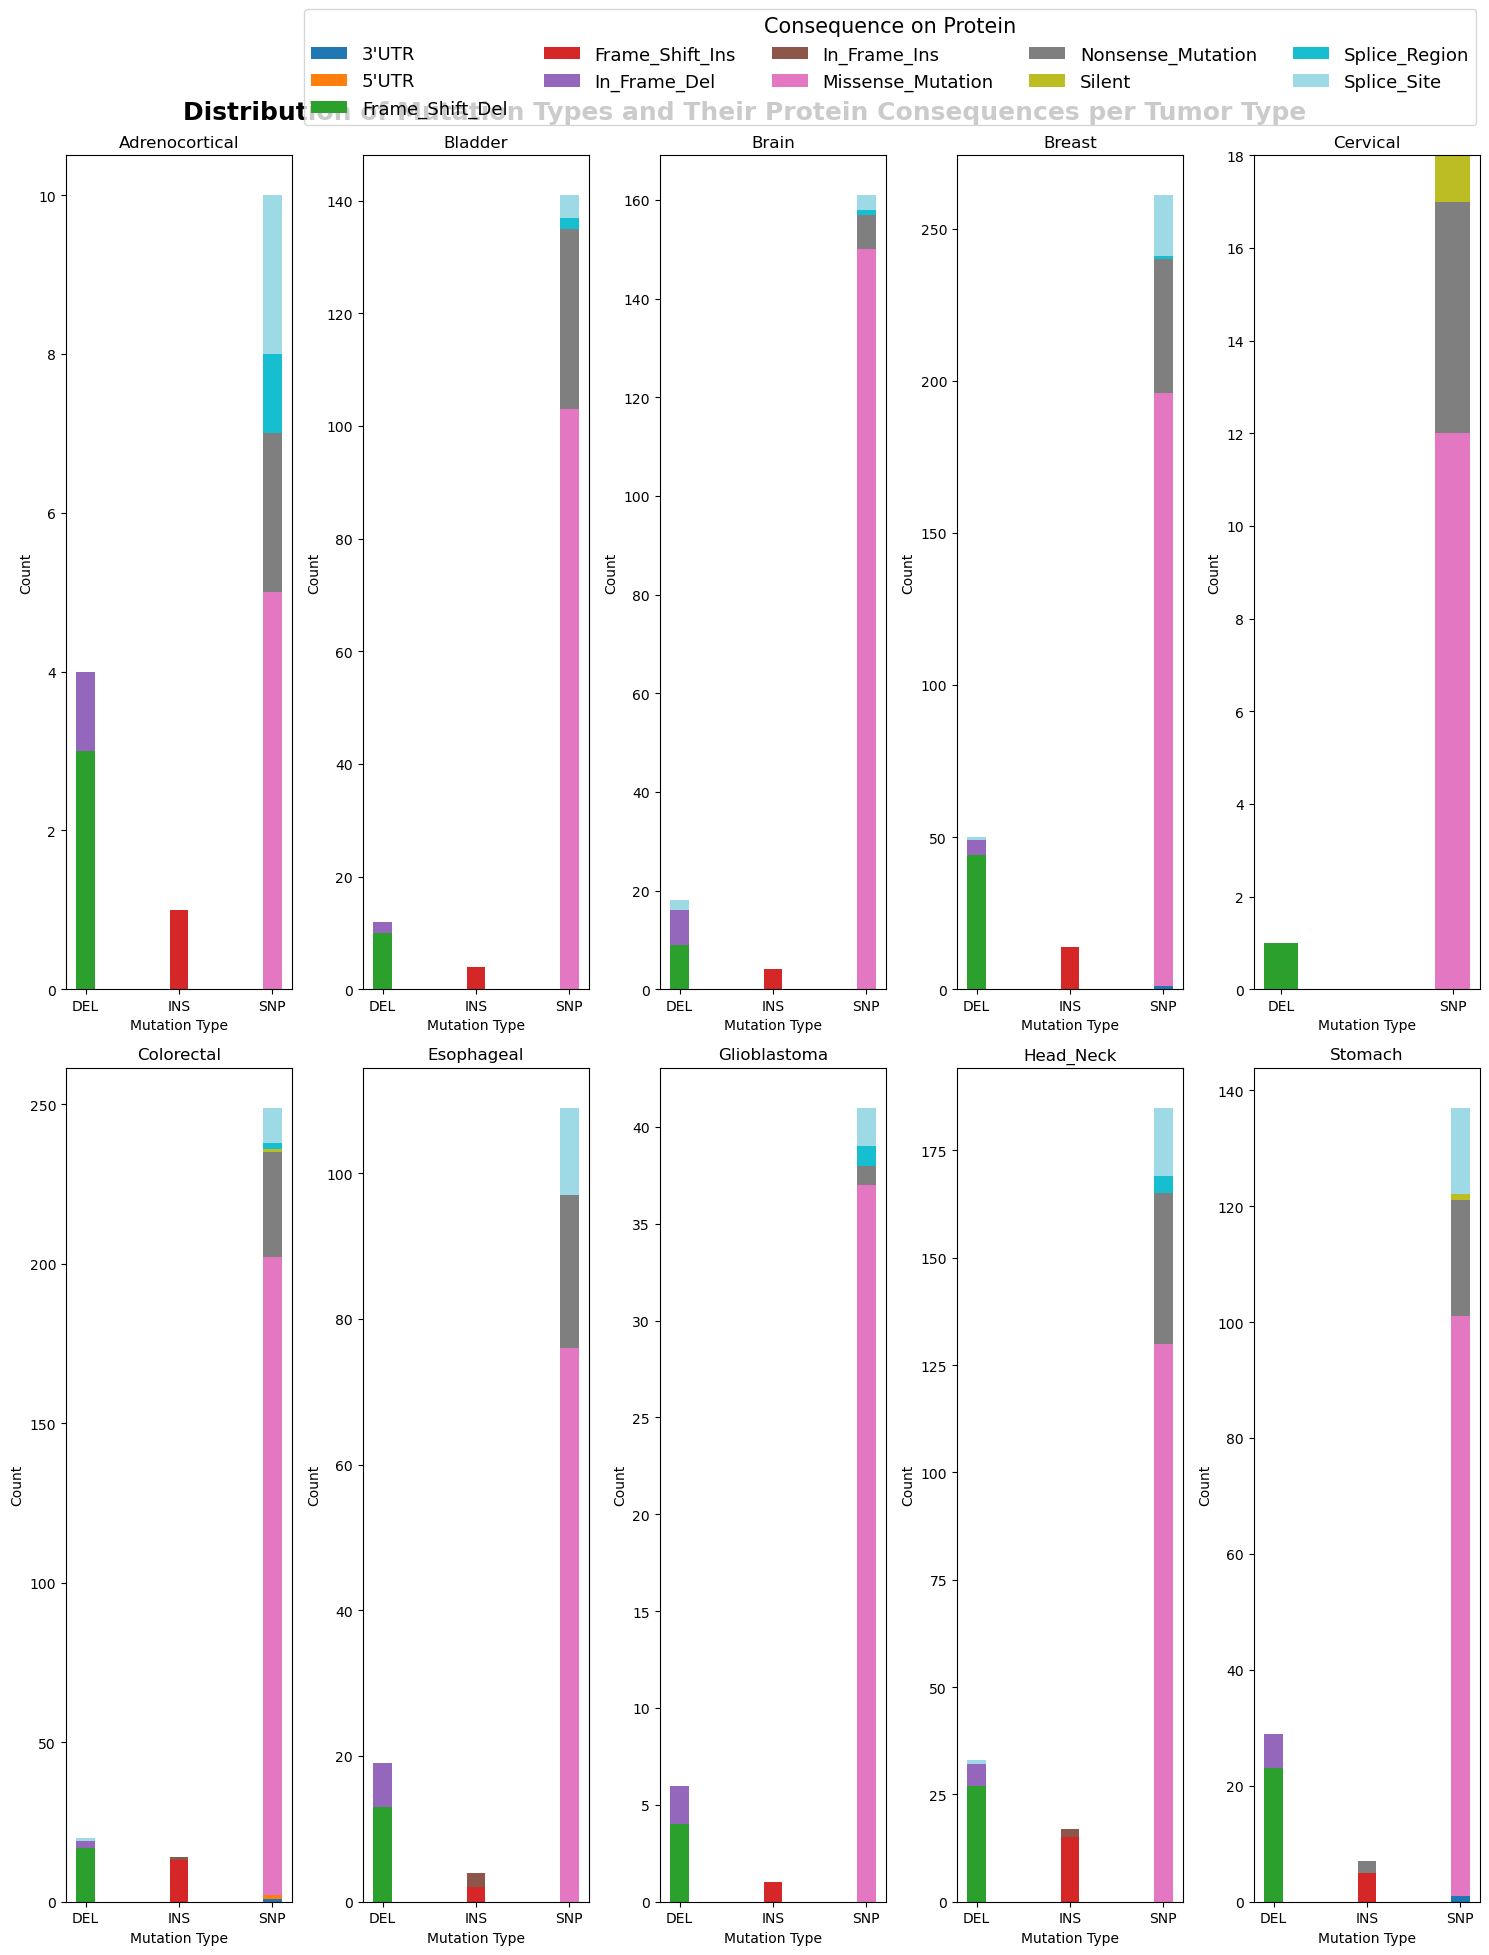

In [23]:
unique_protein_conseq = set()
for df in tcga_study.values():
    unique_protein_conseq.update(df['Protein_Conseq'].dropna().unique())
unique_protein_conseq = sorted(unique_protein_conseq)

color_palette = plt.cm.get_cmap('tab20', len(unique_protein_conseq))
protein_conseq_colors = {pc: color_palette(i) for i, pc in enumerate(unique_protein_conseq)}

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 20))
axes = axes.flatten()

for ax, (tumor_name, df) in zip(axes, tcga_study.items()):
    mut_df = df[df['Mutated'] == 1]
    counts = mut_df.groupby(['Mutation_Type', 'Protein_Conseq']).size().reset_index(name='Count')
    if not counts.empty:
        mutation_types = counts['Mutation_Type'].unique()
        bottom = {mt: 0 for mt in mutation_types}
        for pc in unique_protein_conseq:
            subset = counts[counts['Protein_Conseq'] == pc]
            heights = []
            bottoms = []
            x_labels = []
            for mt in mutation_types:
                value = subset[subset['Mutation_Type'] == mt]['Count'].values
                h = value[0] if len(value) > 0 else 0
                heights.append(h)
                bottoms.append(bottom[mt])
                bottom[mt] += h
                x_labels.append(mt)
            ax.bar(x_labels, heights, bottom=bottoms, label=pc, color=protein_conseq_colors[pc], width=0.2)
        ax.set_title(tumor_name)
        ax.set_xlabel('Mutation Type')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=0)
    else:
        ax.set_title(tumor_name + ' (No mutations)')
        ax.axis('off')

for i in range(len(tcga_study), len(axes)):
    axes[i].axis('off')

fig.legend(protein_conseq_colors.keys(), title='Consequence on Protein',
           loc='upper left', ncol=5, fontsize=13, title_fontsize=15,
            bbox_to_anchor=(0.2, 1.03))
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.suptitle("Distribution of Mutation Types and Their Protein Consequences per Tumor Type", fontsize=18, weight='bold')
plt.show()

Now we want to create a unique dataset, thus we retain only the common genes and concatenate vertically in the rows.

## **Final Dataset - RAW**

In [24]:
def merge_studies_df(cancer_df_dict):
    metadata_cols = ['Mutated', 'Mutation_Type', 'Protein_Conseq', 'Functional_Conseq', 'Tumor_Type']

    gene_sets = [set(df.columns) - set(metadata_cols) for df in cancer_df_dict.values()]
    common_genes = set.intersection(*gene_sets)

    filtered_dfs = []
    for df in cancer_df_dict.values():
        cols = sorted(common_genes) + metadata_cols
        filtered_df = df[cols].copy()
        filtered_dfs.append(filtered_df)

    merged_df = pd.concat(filtered_dfs, axis=0)
    return merged_df

In [25]:
tcga_df_unfil= merge_studies_df(tcga_study)

In [26]:
tcga_df_unfil.head()

Hugo_Symbol,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,...,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,Mutated,Mutation_Type,Protein_Conseq,Functional_Conseq,Tumor_Type
Patient_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J1-01,16.3305,0.0000,17.2911,182.3920,10373.70,221.8830,54.7550,190.6820,0.0000,0.0,...,648.415,1841.020,1157.540,596.062,715.658,0,WT,NaN,NaN,adrenocortical
TCGA-OR-A5J2-01,9.5987,0.0000,5.6368,239.1580,9844.91,101.6680,0.0000,198.8990,0.0000,0.0,...,1166.020,3059.990,1895.990,801.637,581.801,1,DEL,Frame_Shift_Del,NaN,adrenocortical
TCGA-OR-A5J3-01,20.7377,0.5925,8.8876,138.8830,7201.84,70.5673,1.7775,75.2481,2.3700,0.0,...,806.399,2655.610,1482.450,437.269,126.796,0,WT,NaN,NaN,adrenocortical
TCGA-OR-A5J5-01,1696.6600,1.5492,6.1967,63.9349,2939.04,123.7030,49.5740,374.9030,0.7746,0.0,...,553.834,2367.930,1140.200,512.781,855.151,1,SNP,Missense_Mutation,deleterious(0),adrenocortical
TCGA-OR-A5J6-01,600.1620,0.0000,4.4709,237.3520,9586.96,89.6406,1.1177,1556.4200,0.5589,0.0,...,795.812,708.071,796.371,475.587,288.370,0,WT,NaN,NaN,adrenocortical
